In [96]:
import numpy as np 
import pandas as pd
import operator
import os
import chart_studio.tools as tls

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
from matplotlib.backend_bases import RendererBase
from scipy import signal
from scipy.io import wavfile

import os
import numpy as np

from PIL import Image

from scipy.fftpack import fft
import librosa
import librosa.display

import plotly as py
tls.set_credentials_file(username='iam4tart',api_key='Docq9bPOpIqBxnDmPIxJ')

import chart_studio.plotly as py
import plotly.graph_objs as go

import cufflinks as cf
import IPython.display as ipd


In [97]:
def get_files_with_features(path):
    data_ = []
    count = {}
    files = os.listdir(path)
    for file in files:
        labels = file.split("-")[:3]
        if len(labels) < 3:
            continue 
        data = {
            "keyword": labels[0],
            "stress": labels[2],
            "environment": labels[1],
            "path": os.path.join(path, file)
        }
        for label in labels:
            if label not in count.keys():
                count[label] = 1
            else:
                count[label] += 1

        data_.append(data)

    if data_:
        df = pd.DataFrame(data_)
    else:
        df = pd.DataFrame(columns=['keyword', 'stress', 'environment', 'path'])
    return data_, count, df

# Example usage
path = '/Users/pabitraghosh/convertaudio/AudioToSpectogram/spectrograms'
dataset_with_features, count, df_with_features = get_files_with_features(path)
print(df_with_features.head())

      keyword stress environment  \
0          go   calm        safe   
1        help   calm        safe   
2  background   calm        safe   
3  background   calm        safe   
4         yes  happy        safe   

                                                path  
0  /Users/pabitraghosh/convertaudio/AudioToSpecto...  
1  /Users/pabitraghosh/convertaudio/AudioToSpecto...  
2  /Users/pabitraghosh/convertaudio/AudioToSpecto...  
3  /Users/pabitraghosh/convertaudio/AudioToSpecto...  
4  /Users/pabitraghosh/convertaudio/AudioToSpecto...  


In [98]:
df_with_features.count()

keyword        15555
stress         15555
environment    15555
path           15555
dtype: int64

In [99]:
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.callbacks import EarlyStopping, ReduceLROnPlateau



In [100]:
images = []
labels = []

for index, row in df_with_features.iterrows():
    image = cv2.imread(row['path'])
    image = cv2.resize(image, (64, 64))  # Resize images to a common size
    images.append(image)
    labels.append(row['stress'])

images = np.array(images)
labels = np.array(labels)

In [101]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)


In [102]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)


In [103]:
from sklearn.preprocessing import LabelEncoder

# Assuming y_train and y_test are your label arrays

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Fit and transform the training labels (y_train)
y_train_encoded = label_encoder.fit_transform(y_train)

# Transform the test labels (y_test) using the fitted encoder
y_test_encoded = label_encoder.transform(y_test)


In [104]:
num_classes = df_with_features['stress'].nunique()
print(num_classes)

5


In [105]:
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(5, activation='softmax'))

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [106]:
# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.0001)

# Train the model
history = model.fit(X_train, y_train_encoded, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping, reduce_lr])

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test_encoded)
print(f'Test accuracy: {test_acc}')

Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.5447 - loss: 5.1425 - val_accuracy: 0.6530 - val_loss: 1.0083 - learning_rate: 0.0010
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6580 - loss: 0.9408 - val_accuracy: 0.6418 - val_loss: 0.9897 - learning_rate: 0.0010
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6916 - loss: 0.8472 - val_accuracy: 0.6747 - val_loss: 0.9196 - learning_rate: 0.0010
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.7201 - loss: 0.7618 - val_accuracy: 0.6948 - val_loss: 0.9224 - learning_rate: 0.0010
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7504 - loss: 0.6769 - val_accuracy: 0.6956 - val_loss: 0.9556 - learning_rate: 0.0010
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.7854 - loss: 0.5949 - val_accuracy: 0.7084 - val_loss: 1.0321 - learning_rate: 0.0010
Epoch 7/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.8

In [107]:
from keras.applications import ResNet50
from keras.layers import GlobalAveragePooling2D, Dropout

# Load pre-trained ResNet50 model (excluding the top layer)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze the base model layers
base_model.trainable = False

# Add custom layers on top of the base model
model1 = Sequential()
model1.add(base_model)
model1.add(GlobalAveragePooling2D())
model1.add(Dense(256, activation='relu'))
model1.add(Dropout(0.5))  # Add dropout for regularization
model1.add(Dense(num_classes, activation='softmax'))  # Assuming num_classes = 5

# Compile the model
model1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Assuming X_train, X_test, y_train_encoded, y_test_encoded are already prepared

# Define the callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.0001)

# Train the model using X_train and y_train_encoded
history = model1.fit(X_train, y_train_encoded, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping, reduce_lr])

# Evaluate the model using X_test and y_test_encoded
test_loss, test_acc = model1.evaluate(X_test, y_test_encoded)
print(f'Test accuracy: {test_acc}')



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 49s 1us/step
Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 36s 98ms/step - accuracy: 0.6074 - loss: 1.2141 - val_accuracy: 0.7060 - val_loss: 0.7926 - learning_rate: 0.0010
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.6826 - loss: 0.8601 - val_accuracy: 0.7317 - val_loss: 0.7354 - learning_rate: 0.0010
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 38s 108ms/step - accuracy: 0.7054 - loss: 0.7830 - val_accuracy: 0.7365 - val_loss: 0.7165 - learning_rate: 0.0010
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 37s 106ms/step - accuracy: 0.7197 - loss: 0.7487 - val_accuracy: 0.7486 - val_loss: 0.7077 - learning_rate: 0.0010
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.7340 - loss: 0.7246 - val_accuracy: 0.7373 - val_loss: 0.6913 - learning_rate: 0.0010
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.7506 - loss: 0.6702 - val_accuracy: 0.7430 - val_loss: 0.6867 - learning_rate: 0.0010
Epoch 7/150
3

In [114]:
from keras.applications import EfficientNetB0 # Choose the desired EfficientNet variant
from keras.layers import GlobalAveragePooling2D, Dropout, Dense
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [115]:
# Define the EfficientNet model
base_model1 = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze base model layers
base_model1.trainable = False

model2 = Sequential()
model2.add(base_model1)
model2.add(GlobalAveragePooling2D())
model2.add(Dense(256, activation='relu'))
model2.add(Dropout(0.5))  # Add dropout for regularization
model2.add(Dense(num_classes, activation='softmax'))


# Compile the model
model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Assuming X_train, X_test, y_train_encoded, y_test_encoded are already prepared

# Define the callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.0001)

# Train the model using X_train and y_train_encoded
history = model2.fit(X_train, y_train_encoded, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping, reduce_lr])

# Evaluate the model using X_test and y_test_encoded
test_loss, test_acc = model2.evaluate(X_test, y_test_encoded)
print(f'Test accuracy: {test_acc}')


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.5961 - loss: 1.1028 - val_accuracy: 0.6787 - val_loss: 0.9058 - learning_rate: 0.0010
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.6485 - loss: 0.9475 - val_accuracy: 0.6972 - val_loss: 0.8510 - learning_rate: 0.0010
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.6631 - loss: 0.9252 - val_accuracy: 0.7060 - val_loss: 0.8287 - learning_rate: 0.0010
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.6812 - loss: 0.8809 - val_accuracy: 0.7004 - val_loss: 0.8429 - learning_rate: 0.0010
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.6761 - loss: 0.8782 - val_accuracy: 0.7068 - val_loss: 0.8161 - learning_rate: 0.0010
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 41ms/step - accuracy: 0.6832 - loss: 0.8531 - val_accuracy: 0.7213 - val_loss: 0.7938 - learning_rate: 0.0010
Epoch 7/150
350/350

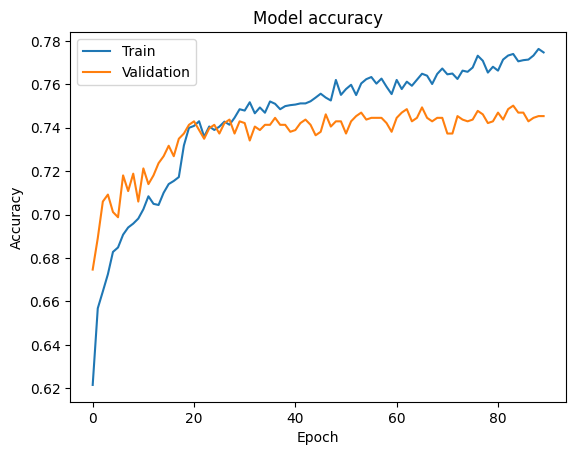

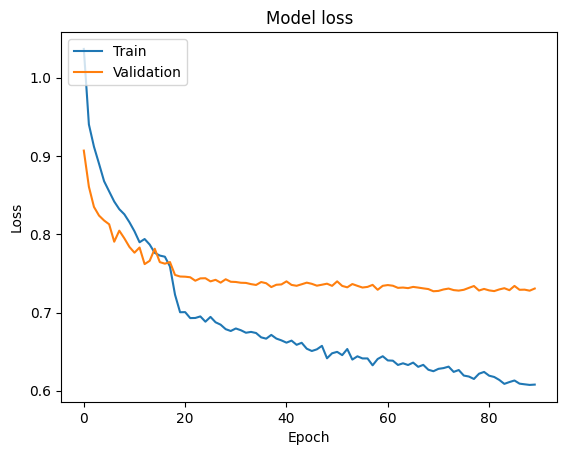

In [119]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [116]:
from keras.applications import EfficientNetB7 # Choose the desired EfficientNet variant
from keras.layers import GlobalAveragePooling2D, Dropout, Dense
from keras.models import Model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [117]:
# Define the EfficientNet model
base_model2 = EfficientNetB7(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

# Freeze base model layers
base_model2.trainable = False

model3 = Sequential()
model3.add(base_model1)
model3.add(GlobalAveragePooling2D())
model3.add(Dense(256, activation='relu'))
model3.add(Dropout(0.5))  # Add dropout for regularization
model3.add(Dense(num_classes, activation='softmax'))


# Compile the model
model3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Assuming X_train, X_test, y_train_encoded, y_test_encoded are already prepared

# Define the callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=20, verbose=1, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.0001)

# Train the model using X_train and y_train_encoded
history = model3.fit(X_train, y_train_encoded, epochs=150, batch_size=32, validation_split=0.1, callbacks=[early_stopping, reduce_lr])

# Evaluate the model using X_test and y_test_encoded
test_loss, test_acc = model3.evaluate(X_test, y_test_encoded)
print(f'Test accuracy: {test_acc}')


258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 117s 0us/step
Epoch 1/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.5958 - loss: 1.1106 - val_accuracy: 0.6747 - val_loss: 0.9069 - learning_rate: 0.0010
Epoch 2/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.6548 - loss: 0.9445 - val_accuracy: 0.6892 - val_loss: 0.8607 - learning_rate: 0.0010
Epoch 3/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 0.6663 - loss: 0.9109 - val_accuracy: 0.7060 - val_loss: 0.8349 - learning_rate: 0.0010
Epoch 4/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.6692 - loss: 0.8909 - val_accuracy: 0.7092 - val_loss: 0.8239 - learning_rate: 0.0010
Epoch 5/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.6866 - loss: 0.8689 - val_accuracy: 0.7012 - val_loss: 0.8176 - learning_rate: 0.0010
Epoch 6/150
350/350 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.6957 - loss: 0.8410 - val_accuracy: 0.6988 - val_loss: 0.8127 - learning_rate: 0.0010
Epoch 7/150
350

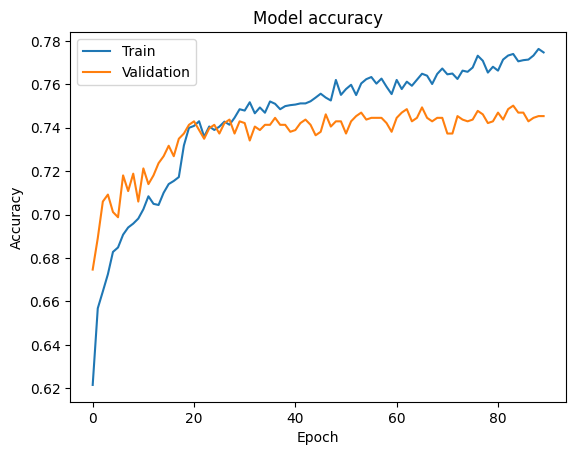

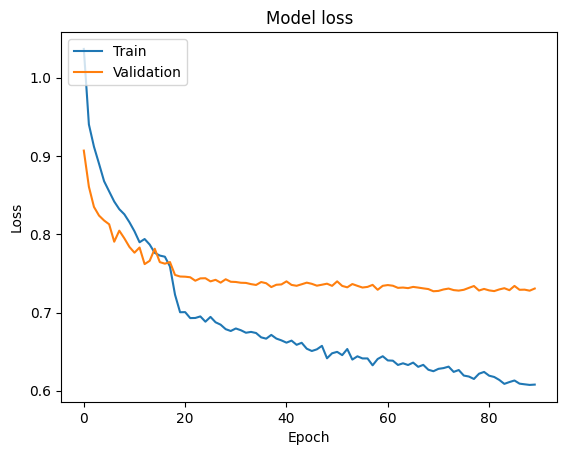

In [118]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()